<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/FNMA_Personalised_Recovery_Scoring_STANDALONE_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FNMA personalised recovery scoring
## Standalone Google Colab notebook

This notebook answers a different question from the Early Warning System:

- **EWS:** Which performing loans are likely to become non-performing?
- **Recovery score:** Once a loan first reaches 90+ DPD, what is its probability of confirmed cure, clean exit or distressed exit within 6, 12 and 24 months?

The notebook is completely standalone. It uses only `fnma_clean_master.parquet` and the accepted loan split; it does not require the Markov notebook to be open or previously executed.


## 1. Setup and data contract

The accepted split is reused so that comparisons remain honest. The clean Fannie source is the preferred input; the raw CSV is only a fallback. Edit `PROJECT_DIR` in the next cell if required.


In [2]:
from pathlib import Path
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = str

import json
import math
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Edit this one path only if your Drive folder differs.
PROJECT_DIR = Path(os.environ.get(
    "FIP_PROJECT_DIR",
    "/content/drive/MyDrive/FIP_NPL_Project",
)).expanduser()
OUTPUT_DIR = Path(os.environ.get(
    "FIP_PERSONALISED_RECOVERY_OUTPUT_DIR",
    PROJECT_DIR / "model_outputs_personalised_recovery",
)).expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CUSTOM_SOURCE = os.environ.get("FIP_CLEAN_SOURCE")
CUSTOM_SPLIT = os.environ.get("FIP_SPLIT_PATH")
SOURCE_CANDIDATES = [
    PROJECT_DIR / "fnma_clean_master.parquet",
    PROJECT_DIR / "FNMA_MF_Loan_Performance_Data_202603.csv",
]
SPLIT_CANDIDATES = [
    PROJECT_DIR / "model_outputs_grouped_loan_shuffle_24m" / "loan_split_assignments_seed42.csv",
    PROJECT_DIR / "model_outputs_feature_elimination_24m" / "loan_split_assignments_seed42.csv",
]

PRIMARY_CURE_MONTHS = 3
CURE_SENSITIVITY_MONTHS = [1, 3]
Q2_EVENTS = ["CURED_CONFIRMED", "EXIT_CLEAN", "EXIT_DISTRESSED", "EXIT_ADMIN_OTHER"]
BOOTSTRAP_REPS = int(os.environ.get("RECOVERY_BOOTSTRAP_REPS", "500"))

EXIT_MAP = {
    "Fully Paid, Matured": "EXIT_CLEAN",
    "Fully Paid, Prepaid": "EXIT_CLEAN",
    "Fully Paid, Refinance": "EXIT_CLEAN",
    "Fully Paid, Refinanced": "EXIT_CLEAN",
    "Foreclosure": "EXIT_DISTRESSED",
    "Deed-in-Lieu": "EXIT_DISTRESSED",
    "Third Party Sale": "EXIT_DISTRESSED",
    "Discounted Payoff": "EXIT_DISTRESSED",
    "Other Liquidation": "EXIT_DISTRESSED",
    "Repurchase": "EXIT_ADMIN_OTHER",
    "Substitution": "EXIT_ADMIN_OTHER",
    "Dissolution": "EXIT_ADMIN_OTHER",
    "Other": "EXIT_ADMIN_OTHER",
}

print(f"Project directory: {PROJECT_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")


Mounted at /content/drive
Project directory: /content/drive/MyDrive/FIP_NPL_Project
Output directory:  /content/drive/MyDrive/FIP_NPL_Project/model_outputs_personalised_recovery


In [3]:
def month_start(values):
    parsed = pd.to_datetime(values, errors="coerce")
    return parsed.dt.to_period("M").dt.to_timestamp()


def month_difference(later, earlier):
    later = pd.to_datetime(later)
    earlier = pd.to_datetime(earlier)
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)


def money_to_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    return pd.to_numeric(
        series.astype("string").str.replace(r"[$,()]", "", regex=True),
        errors="coerce",
    )


def save_table(frame, filename, index=False):
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=index)
    return path


def write_json(payload, filename):
    path = OUTPUT_DIR / filename
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return path


def find_first_existing(custom, candidates, label):
    if custom:
        path = Path(custom).expanduser()
        if not path.exists():
            raise FileNotFoundError(f"Configured {label} does not exist: {path}")
        return path
    for path in candidates:
        if path.exists():
            return path
    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find {label}. Searched:\n{searched}")


def era_label(dates):
    years = pd.to_datetime(dates).dt.year
    return pd.cut(
        years,
        bins=[-np.inf, 2008, 2011, 2019, 2021, np.inf],
        labels=["pre_2009", "gfc_2009_11", "post_gfc_2012_19", "covid_2020_21", "rates_2022_plus"],
        right=True,
    ).astype("string")


## 2. Reconstruct post-NPL first-resolution outcomes

The notebook independently identifies first 90+ DPD, applies the frozen Fannie exit mapping, excludes any recorded exit that predates first NPL, and defines cure as three consecutive Current months. This creates the model target without relying on another notebook's memory.


In [4]:
SOURCE_PATH = find_first_existing(CUSTOM_SOURCE, SOURCE_CANDIDATES, "clean Fannie source")
SPLIT_PATH = find_first_existing(CUSTOM_SPLIT, SPLIT_CANDIDATES, "accepted split file")

RAW_REQUESTED = [
    "Loan Number", "Reporting Period Date", "rpd", "Loan Payment Status", "SDQ Indicator",
    "Liquidation/Prepayment Code", "Liquidation/Prepayment Date", "liq_date",
    "UPB - Current", "upb_cur_num",
]

if SOURCE_PATH.suffix.lower() == ".parquet":
    import pyarrow.parquet as pq
    available = pq.ParquetFile(SOURCE_PATH).schema.names
    selected = [name for name in RAW_REQUESTED if name in available]
    df = pd.read_parquet(SOURCE_PATH, columns=selected)
else:
    header = pd.read_csv(SOURCE_PATH, nrows=0).columns.tolist()
    stripped_to_raw = {name.strip(): name for name in header}
    selected = [name for name in RAW_REQUESTED if name in stripped_to_raw]
    df = pd.read_csv(
        SOURCE_PATH,
        usecols=[stripped_to_raw[name] for name in selected],
        low_memory=False,
    )

df.columns = df.columns.str.strip()
if "rpd" in df.columns:
    df["rpd"] = month_start(df["rpd"])
else:
    df["rpd"] = month_start(df["Reporting Period Date"])
df["Loan Number"] = df["Loan Number"].astype("string").str.strip()
df["Loan Payment Status"] = df["Loan Payment Status"].astype("string").str.strip()

if "Liquidation/Prepayment Code" not in df.columns:
    raise KeyError("Clean source lacks Liquidation/Prepayment Code")
df["Liquidation/Prepayment Code"] = (
    df["Liquidation/Prepayment Code"].astype("string").str.strip().replace("", pd.NA)
)
if "liq_date" in df.columns:
    df["liq_date"] = month_start(df["liq_date"])
elif "Liquidation/Prepayment Date" in df.columns:
    df["liq_date"] = month_start(df["Liquidation/Prepayment Date"])
else:
    df["liq_date"] = pd.NaT

if "upb_cur_num" not in df.columns:
    df["upb_cur_num"] = money_to_numeric(df["UPB - Current"])

if df.duplicated(["Loan Number", "rpd"]).any():
    duplicate = df.loc[df.duplicated(["Loan Number", "rpd"], keep=False)]
    if duplicate.drop_duplicates().duplicated(["Loan Number", "rpd"], keep=False).any():
        raise ValueError("Conflicting duplicate loan-month records found")
    df = df.drop_duplicates().copy()

df = df.sort_values(["Loan Number", "rpd"], kind="mergesort").reset_index(drop=True)

loan_split = pd.read_csv(SPLIT_PATH, dtype={"Loan Number": "string"})
loan_split["Loan Number"] = loan_split["Loan Number"].astype("string").str.strip()
loan_split["partition"] = loan_split["partition"].astype("string").str.lower().replace({"val": "validation"})
if loan_split["Loan Number"].duplicated().any():
    raise ValueError("Accepted split contains duplicate loan assignments")
if set(loan_split["partition"].dropna().unique()) != {"train", "validation", "test"}:
    raise ValueError("Accepted split must contain train, validation and test")

print(f"Loaded {len(df):,} loan-month rows and {df['Loan Number'].nunique():,} loans")
print(f"Accepted split: {SPLIT_PATH}")


Loaded 5,392,796 loan-month rows and 73,048 loans
Accepted split: /content/drive/MyDrive/FIP_NPL_Project/model_outputs_grouped_loan_shuffle_24m/loan_split_assignments_seed42.csv


In [5]:
observed_codes = set(df["Liquidation/Prepayment Code"].dropna().unique())
unknown_codes = sorted(observed_codes - set(EXIT_MAP))
if unknown_codes:
    raise ValueError(f"Unmapped liquidation codes: {unknown_codes}")

first_rows = (
    df.groupby("Loan Number", sort=False, as_index=False).head(1)[["Loan Number", "rpd"]]
    .rename(columns={"rpd": "first_rpd"}).set_index("Loan Number")
)
last_rows = (
    df.groupby("Loan Number", sort=False, as_index=False).tail(1)[["Loan Number", "rpd"]]
    .rename(columns={"rpd": "last_rpd"}).set_index("Loan Number")
)
first_npl = (
    df.loc[df["Loan Payment Status"].eq("90+ Days Delinquent")]
    .groupby("Loan Number", sort=False)["rpd"].min().rename("first_npl")
)
terminal = first_rows.join(last_rows, how="outer").join(first_npl, how="left")

# Code and date are kept from the same source row. For later-NPL loans, only
# exits on/after first NPL count as post-NPL recovery outcomes.
exit_records = df.loc[df["Liquidation/Prepayment Code"].notna(), [
    "Loan Number", "rpd", "Liquidation/Prepayment Code", "liq_date"
]].copy()
exit_records["exit_category"] = exit_records["Liquidation/Prepayment Code"].map(EXIT_MAP)
exit_records["exit_event_date"] = pd.to_datetime(exit_records["liq_date"], errors="coerce")
exit_records.loc[exit_records["exit_event_date"].isna(), "exit_event_date"] = exit_records["rpd"]
exit_records["first_npl"] = exit_records["Loan Number"].map(first_npl)

pre_npl_exit_records = exit_records.loc[
    exit_records["first_npl"].notna()
    & exit_records["exit_event_date"].lt(exit_records["first_npl"])
].copy()
pre_npl_exit_records["recovery_treatment"] = (
    "excluded from post-NPL resolution; loan retained and censored unless a later valid exit exists"
)
save_table(pre_npl_exit_records, "pre_npl_exit_records_on_later_npl_loans.csv")

valid_post_npl = exit_records.loc[
    exit_records["first_npl"].notna()
    & exit_records["exit_event_date"].ge(exit_records["first_npl"])
].copy()
first_valid_exit = (
    valid_post_npl.sort_values(["Loan Number", "exit_event_date", "rpd"], kind="mergesort")
    .groupby("Loan Number", as_index=False, sort=False).head(1).set_index("Loan Number")
)
for field in ["Liquidation/Prepayment Code", "liq_date", "exit_category", "exit_event_date"]:
    terminal[field] = first_valid_exit[field].reindex(terminal.index)

terminal["npl_era"] = era_label(terminal["first_npl"])
assignment = loan_split.set_index("Loan Number")["partition"]
terminal["partition"] = terminal.index.to_series().map(assignment)

if (
    terminal["first_npl"].notna()
    & terminal["exit_event_date"].notna()
    & terminal["exit_event_date"].lt(terminal["first_npl"])
).any():
    raise AssertionError("Earlier exit survived the post-NPL outcome filter")

def sustained_cure_dates(source, npl_dates, consecutive_months):
    work = source.loc[source["Loan Number"].isin(npl_dates.index), [
        "Loan Number", "rpd", "Loan Payment Status"
    ]].copy()
    work["first_npl"] = work["Loan Number"].map(npl_dates)
    work = work.loc[work["rpd"].gt(work["first_npl"])].sort_values(["Loan Number", "rpd"])
    work["is_current"] = work["Loan Payment Status"].eq("Current")
    work["prev_current"] = work.groupby("Loan Number", sort=False)["is_current"].shift(1, fill_value=False)
    work["prev_date"] = work.groupby("Loan Number", sort=False)["rpd"].shift(1)
    work["gap_m"] = month_difference(work["rpd"], work["prev_date"])
    continuing = work["is_current"] & work["prev_current"] & work["gap_m"].eq(1)
    work["run_id"] = (work["is_current"] & ~continuing).groupby(work["Loan Number"]).cumsum()
    current = work.loc[work["is_current"]].copy()
    current["streak"] = current.groupby(["Loan Number", "run_id"], sort=False).cumcount() + 1
    return (
        current.loc[current["streak"].ge(consecutive_months)]
        .groupby("Loan Number", sort=False)["rpd"].min()
        .rename(f"cure_date_{consecutive_months}m")
    )


def build_first_resolution(terminal_table, cure_dates, cure_months):
    out = terminal_table.loc[
        terminal_table["first_npl"].notna() & terminal_table["partition"].notna(),
        ["first_npl", "last_rpd", "exit_event_date", "exit_category", "partition", "npl_era"],
    ].copy().join(cure_dates, how="left")
    cure_col = cure_dates.name
    cure_first = out[cure_col].notna() & (
        out["exit_event_date"].isna() | out[cure_col].lt(out["exit_event_date"])
    )
    out["event"] = "CENSORED"
    out.loc[out["exit_category"].notna(), "event"] = out.loc[out["exit_category"].notna(), "exit_category"]
    out.loc[cure_first, "event"] = "CURED_CONFIRMED"
    out["event_observed"] = out["event"].ne("CENSORED")
    out["event_date"] = out["exit_event_date"]
    out.loc[cure_first, "event_date"] = out.loc[cure_first, cure_col]
    out.loc[~out["event_observed"], "event_date"] = out.loc[~out["event_observed"], "last_rpd"]
    out["duration_m"] = month_difference(out["event_date"], out["first_npl"]).clip(lower=0).astype(int)
    out["cure_definition_months"] = cure_months
    return out.reset_index()


assigned_npl_dates = terminal.loc[
    terminal["first_npl"].notna() & terminal["partition"].notna(), "first_npl"
]
resolution_by_definition = {
    months: build_first_resolution(
        terminal,
        sustained_cure_dates(df, assigned_npl_dates, months),
        months,
    )
    for months in CURE_SENSITIVITY_MONTHS
}
first_events = resolution_by_definition[PRIMARY_CURE_MONTHS]
save_table(first_events, "q2_first_resolution_events_primary.csv")

event_summary = (
    first_events["event"].value_counts(dropna=False)
    .rename_axis("first_resolution").reset_index(name="loans")
)
event_summary["share_pct"] = 100 * event_summary["loans"] / len(first_events)
split_summary = first_events.groupby("partition").size().rename("npl_loans").reset_index()

print(f"Earlier exit records excluded: {pre_npl_exit_records['Loan Number'].nunique():,} loans")
display(event_summary.round(3))
display(split_summary)


Earlier exit records excluded: 2 loans


,first_resolution,loans,share_pct
0,EXIT_DISTRESSED,567,38.969
1,CURED_CONFIRMED,461,31.684
2,EXIT_CLEAN,282,19.381
3,CENSORED,124,8.522
4,EXIT_ADMIN_OTHER,21,1.443


,partition,npl_loans
0,test,291
1,train,885
2,validation,279


## 3. Frozen modelling decisions

Pre-declares the estimator, feature ceiling, censoring-aware metrics and promotion rule before any validation or test result is examined.


In [6]:
# -----------------------------------------------------------------------------
# 0. Preconditions and pre-declared decisions
# -----------------------------------------------------------------------------

REQUIRED_NOTEBOOK_OBJECTS = [
    "SOURCE_PATH", "OUTPUT_DIR", "df", "terminal", "first_events",
    "save_table", "write_json", "month_start", "month_difference",
]
missing_objects = [name for name in REQUIRED_NOTEBOOK_OBJECTS if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the existing recovery notebook from the top before this appended cell. "
        f"Missing objects: {missing_objects}"
    )

RECOVERY_MODEL_SEED = 4251
RECOVERY_MAX_HORIZON = 24
RECOVERY_REPORT_HORIZONS = [6, 12, 24]
RECOVERY_EVENTS = ["CURED_CONFIRMED", "EXIT_CLEAN", "EXIT_DISTRESSED"]
NO_EVENT = "NO_EVENT"

# Frozen before results are inspected.
LANDMARK_COVERAGE_THRESHOLD = 0.70
LOGISTIC_C_GRID = [0.01, 0.03, 0.10, 0.30, 1.00]
LOGISTIC_TIE_TOLERANCE_IBS = 0.001
BOOSTER_REQUIRED_VALIDATION_GAIN = 0.005
PROMOTION_MIN_RELATIVE_IBS_GAIN = 0.02
PAIRED_BOOTSTRAP_REPS = int(os.environ.get(
    "RECOVERY_SCORE_BOOTSTRAP_REPS",
    str(globals().get("BOOTSTRAP_REPS", 500)),
))
PAIRED_BOOTSTRAP_ALPHA = 0.05
CALIBRATION_GROUPS = 5

# Ten deliberately compact, deployable landmark covariates. No hard-coded era.
PREDECLARED_COVARIATES = [
    "log_current_upb",
    "pct_amortized_clean",
    "log_underwritten_dscr",
    "acquisition_ltv_clean",
    "occupancy_clean",
    "loan_age_m",
    "months_to_current_maturity",
    "late_share_prior12",
    "previous_status_severity",
    "ever_modified_to_npl",
]
TIME_COVARIATES = ["log_month_since_npl", "post12_time_slope"]

DECISION_RULE = (
    "Promote the selected personalised model only if, on the held-out test loans, "
    "the whole-loan paired bootstrap 95% CI for delta integrated IPCW Brier "
    "(personalised minus duration-only) is entirely below zero AND the observed "
    "relative Brier improvement is at least 2%. Otherwise retain the duration-only "
    "first-resolution model. Validation chooses all model settings; test is used once."
)


## 4. First-NPL landmark dataset

Loads only assigned NPL loans, constructs deployable borrower/loan features using information available at first NPL, and audits coverage before choosing the usable feature list.


In [7]:
# -----------------------------------------------------------------------------
# 1. Load only the assigned NPL loans and build first-NPL landmark features
# -----------------------------------------------------------------------------

def _first_present(columns, candidates):
    return next((name for name in candidates if name in columns), None)


def _numeric(series):
    if series is None:
        return pd.Series(dtype=float)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.replace(r"[$,()]", "", regex=True)
        .replace({"": pd.NA, "<NA>": pd.NA})
    )
    return pd.to_numeric(cleaned, errors="coerce")


def _read_feature_rows(path, loan_ids):
    """Read selected columns for only the assigned NPL loans where possible."""
    path = Path(path)
    candidates = [
        "Loan Number", "rpd", "Reporting Period Date", "Loan Payment Status",
        "upb_cur_num", "UPB - Current", "orig_upb_num", "Original UPB",
        "dscr_clean", "Underwritten DSCR", "ltv_clean", "Loan Acquisition LTV",
        "occ_clean", "Physical Occupancy %", "note_date", "Note Date",
        "mat_cur_date", "Maturity Date - Current", "Modification Indicator",
    ]

    if path.suffix.lower() == ".parquet":
        import pyarrow as pa
        import pyarrow.dataset as pads

        dataset = pads.dataset(str(path), format="parquet")
        selected = [name for name in candidates if name in dataset.schema.names]
        if "Loan Number" not in selected:
            raise KeyError("Clean source has no Loan Number column")

        loan_type = dataset.schema.field("Loan Number").type
        raw_ids = list(pd.Series(list(loan_ids), dtype="string").dropna().unique())
        if pa.types.is_integer(loan_type):
            typed_ids = [int(float(value)) for value in raw_ids]
        elif pa.types.is_floating(loan_type):
            typed_ids = [float(value) for value in raw_ids]
        else:
            typed_ids = [str(value) for value in raw_ids]

        try:
            table = dataset.to_table(
                columns=selected,
                filter=pads.field("Loan Number").isin(typed_ids),
            )
            return table.to_pandas()
        except Exception as exc:
            warnings.warn(
                f"Predicate pushdown failed ({exc}); reading selected columns and filtering in memory.",
                RuntimeWarning,
            )
            frame = pd.read_parquet(path, columns=selected)
            keep = frame["Loan Number"].astype("string").str.strip().isin(set(map(str, raw_ids)))
            return frame.loc[keep].copy()

    header = pd.read_csv(path, nrows=0).columns.tolist()
    stripped_to_raw = {name.strip(): name for name in header}
    selected_stripped = [name for name in candidates if name in stripped_to_raw]
    usecols = [stripped_to_raw[name] for name in selected_stripped]
    id_set = set(map(str, loan_ids))
    chunks = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=250_000, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        keep = chunk["Loan Number"].astype("string").str.strip().isin(id_set)
        if keep.any():
            chunks.append(chunk.loc[keep].copy())
    if not chunks:
        raise ValueError("No assigned NPL loans were found in the clean source")
    return pd.concat(chunks, ignore_index=True)


assigned_events = first_events.copy()
assigned_events["Loan Number"] = assigned_events["Loan Number"].astype("string").str.strip()
assigned_events["duration_m"] = pd.to_numeric(assigned_events["duration_m"], errors="raise").astype(int)
assigned_events["target_event"] = assigned_events["event"].where(
    assigned_events["event"].isin(RECOVERY_EVENTS), "CENSORED"
)
assigned_events["censor_reason"] = np.select(
    [
        assigned_events["event"].eq("EXIT_ADMIN_OTHER"),
        assigned_events["event"].eq("CENSORED"),
    ],
    ["ADMIN_EXIT", "END_OF_OBSERVATION"],
    default="TARGET_EVENT_OBSERVED",
)

npl_ids = assigned_events["Loan Number"].unique().tolist()
feature_rows = _read_feature_rows(SOURCE_PATH, npl_ids)
feature_rows.columns = feature_rows.columns.str.strip()
feature_rows["Loan Number"] = feature_rows["Loan Number"].astype("string").str.strip()

rpd_col = _first_present(feature_rows.columns, ["rpd", "Reporting Period Date"])
if rpd_col is None:
    raise KeyError("Feature source lacks rpd/Reporting Period Date")
feature_rows["_rpd"] = month_start(feature_rows[rpd_col])

npl_map = assigned_events.set_index("Loan Number")["first_npl"]
feature_rows["_first_npl"] = feature_rows["Loan Number"].map(npl_map)
feature_rows = feature_rows.loc[
    feature_rows["_first_npl"].notna()
    & feature_rows["_rpd"].le(feature_rows["_first_npl"])
].sort_values(["Loan Number", "_rpd"], kind="mergesort")

landmark_raw = feature_rows.loc[
    feature_rows["_rpd"].eq(feature_rows["_first_npl"])
].drop_duplicates("Loan Number", keep="last").set_index("Loan Number")

missing_landmarks = sorted(set(npl_ids) - set(landmark_raw.index.astype(str)))
if missing_landmarks:
    raise ValueError(
        f"{len(missing_landmarks)} assigned NPL loans have no source row at first NPL. "
        f"Examples: {missing_landmarks[:10]}"
    )

upb_cur_col = _first_present(landmark_raw.columns, ["upb_cur_num", "UPB - Current"])
orig_upb_col = _first_present(landmark_raw.columns, ["orig_upb_num", "Original UPB"])
dscr_col = _first_present(landmark_raw.columns, ["dscr_clean", "Underwritten DSCR"])
ltv_col = _first_present(landmark_raw.columns, ["ltv_clean", "Loan Acquisition LTV"])
occ_col = _first_present(landmark_raw.columns, ["occ_clean", "Physical Occupancy %"])
note_col = _first_present(landmark_raw.columns, ["note_date", "Note Date"])
mat_col = _first_present(landmark_raw.columns, ["mat_cur_date", "Maturity Date - Current"])

landmark = pd.DataFrame(index=pd.Index(npl_ids, name="Loan Number"))
landmark["first_npl"] = landmark.index.to_series().map(npl_map)
landmark["npl_era_diagnostic"] = pd.cut(
    pd.to_datetime(landmark["first_npl"]).dt.year,
    bins=[-np.inf, 2008, 2011, 2019, 2021, np.inf],
    labels=["pre_2009", "gfc_2009_11", "post_gfc_2012_19", "covid_2020_21", "rates_2022_plus"],
    right=True,
).astype("string")

current_upb = _numeric(landmark_raw[upb_cur_col]).reindex(landmark.index) if upb_cur_col else np.nan
original_upb = _numeric(landmark_raw[orig_upb_col]).reindex(landmark.index) if orig_upb_col else np.nan
dscr = _numeric(landmark_raw[dscr_col]).reindex(landmark.index) if dscr_col else np.nan
ltv = _numeric(landmark_raw[ltv_col]).reindex(landmark.index) if ltv_col else np.nan
occupancy = _numeric(landmark_raw[occ_col]).reindex(landmark.index) if occ_col else np.nan

landmark["log_current_upb"] = np.log1p(pd.Series(current_upb, index=landmark.index).clip(lower=0))
pct_amortized = 1.0 - pd.Series(current_upb, index=landmark.index) / pd.Series(original_upb, index=landmark.index)
landmark["pct_amortized_clean"] = pct_amortized.where(pct_amortized.between(-1.0, 1.0))
landmark["log_underwritten_dscr"] = np.log1p(pd.Series(dscr, index=landmark.index).where(pd.Series(dscr, index=landmark.index).ge(0)))
landmark["acquisition_ltv_clean"] = pd.Series(ltv, index=landmark.index).where(pd.Series(ltv, index=landmark.index).between(0.01, 120.0))
landmark["occupancy_clean"] = pd.Series(occupancy, index=landmark.index).where(pd.Series(occupancy, index=landmark.index).between(0.01, 100.0))

if note_col:
    note_dates = pd.to_datetime(landmark_raw[note_col], errors="coerce").reindex(landmark.index)
    landmark["loan_age_m"] = month_difference(landmark["first_npl"], note_dates)
else:
    landmark["loan_age_m"] = np.nan

if mat_col:
    maturity_dates = pd.to_datetime(landmark_raw[mat_col], errors="coerce").reindex(landmark.index)
    landmark["months_to_current_maturity"] = month_difference(maturity_dates, landmark["first_npl"])
else:
    landmark["months_to_current_maturity"] = np.nan

if "Modification Indicator" in feature_rows.columns:
    modified = (
        feature_rows["Modification Indicator"].astype("string").str.strip().str.upper().eq("Y")
        .groupby(feature_rows["Loan Number"]).max().astype(float)
    )
    landmark["ever_modified_to_npl"] = landmark.index.to_series().map(modified)
else:
    landmark["ever_modified_to_npl"] = np.nan

# Strictly pre-NPL behavioural features from the already-loaded compact dataframe.
history = df.loc[df["Loan Number"].isin(npl_ids), [
    "Loan Number", "rpd", "Loan Payment Status"
]].copy()
history["first_npl"] = history["Loan Number"].map(npl_map)
history = history.loc[history["rpd"].lt(history["first_npl"])].copy()
status_severity = {
    "Current": 0,
    "30-59 Days Delinquent": 1,
    "60-89 Days Delinquent": 2,
    "90+ Days Delinquent": 3,
}
history["severity"] = history["Loan Payment Status"].map(status_severity)
history["months_before_npl"] = month_difference(history["first_npl"], history["rpd"])
prior12 = history.loc[history["months_before_npl"].between(1, 12)].copy()
prior12_summary = prior12.groupby("Loan Number").agg(
    prior12_observed_months=("severity", "size"),
    prior12_late_months=("severity", lambda values: int((values > 0).sum())),
)
prior12_summary["late_share_prior12"] = (
    prior12_summary["prior12_late_months"]
    / prior12_summary["prior12_observed_months"].replace(0, np.nan)
)
previous_severity = (
    history.sort_values(["Loan Number", "rpd"])
    .groupby("Loan Number")["severity"].last()
)
landmark["late_share_prior12"] = landmark.index.to_series().map(prior12_summary["late_share_prior12"])
landmark["previous_status_severity"] = landmark.index.to_series().map(previous_severity)

landmark = landmark.reset_index().merge(
    assigned_events[["Loan Number", "partition", "event", "target_event", "censor_reason", "duration_m"]],
    on="Loan Number",
    how="left",
    validate="one_to_one",
)

coverage_rows = []
for partition in ["all", "train", "validation", "test"]:
    group = landmark if partition == "all" else landmark.loc[landmark["partition"].eq(partition)]
    for feature in PREDECLARED_COVARIATES:
        coverage_rows.append({
            "partition": partition,
            "feature": feature,
            "loans": len(group),
            "populated_loans": int(group[feature].notna().sum()),
            "coverage_pct": 100.0 * group[feature].notna().mean() if len(group) else np.nan,
        })
coverage_audit = pd.DataFrame(coverage_rows)
save_table(coverage_audit, "recovery_landmark_covariate_coverage.csv")

train_coverage = (
    coverage_audit.loc[coverage_audit["partition"].eq("train")]
    .set_index("feature")["coverage_pct"].div(100.0)
)
MODEL_COVARIATES = [
    feature for feature in PREDECLARED_COVARIATES
    if train_coverage.get(feature, 0.0) >= LANDMARK_COVERAGE_THRESHOLD
]
excluded_covariates = sorted(set(PREDECLARED_COVARIATES) - set(MODEL_COVARIATES))
if len(MODEL_COVARIATES) < 4:
    raise ValueError(
        "Fewer than four pre-declared covariates meet the 70% training coverage rule. "
        f"Retained: {MODEL_COVARIATES}; excluded: {excluded_covariates}"
    )

feature_decisions = pd.DataFrame({
    "feature": PREDECLARED_COVARIATES,
    "training_coverage_pct": [100.0 * train_coverage.get(name, 0.0) for name in PREDECLARED_COVARIATES],
    "retained": [name in MODEL_COVARIATES for name in PREDECLARED_COVARIATES],
    "rule": f"retain if training landmark coverage >= {LANDMARK_COVERAGE_THRESHOLD:.0%}",
})
save_table(feature_decisions, "recovery_personalised_feature_decisions.csv")

event_counts = (
    landmark.groupby(["partition", "event"], dropna=False)
    .size().rename("loans").reset_index()
)
save_table(event_counts, "recovery_personalised_event_counts.csv")

del feature_rows, landmark_raw, history, prior12


## 5. Discrete-time competing-risks models

Creates one at-risk record per loan-month and converts monthly multinomial hazards into cumulative probabilities of cure, clean exit and distressed exit.


In [8]:
# -----------------------------------------------------------------------------
# 2. Discrete-time competing-risk construction and prediction
# -----------------------------------------------------------------------------

def _event_month(duration):
    return max(1, int(duration))


def build_person_month_panel(landmark_frame, max_horizon=RECOVERY_MAX_HORIZON):
    rows = []
    for record in landmark_frame.to_dict("records"):
        duration = max(0, int(record["duration_m"]))
        original_event = record["event"]
        target_event = record["target_event"]

        if target_event in RECOVERY_EVENTS:
            terminal_month = _event_month(duration)
            last_month = min(terminal_month, max_horizon)
        elif original_event == "EXIT_ADMIN_OTHER":
            # Censor immediately before the administrative competing event.
            last_month = min(max(_event_month(duration) - 1, 0), max_horizon)
        else:
            # End-of-observation censoring: observed event-free through duration.
            last_month = min(duration, max_horizon)

        for month in range(1, last_month + 1):
            row = {
                "Loan Number": record["Loan Number"],
                "partition": record["partition"],
                "month_since_npl": month,
                "log_month_since_npl": math.log1p(month),
                "post12_time_slope": max(month - 12, 0) / 12.0,
                "monthly_outcome": (
                    target_event
                    if target_event in RECOVERY_EVENTS and month == _event_month(duration)
                    else NO_EVENT
                ),
            }
            for feature in MODEL_COVARIATES:
                row[feature] = record[feature]
            row["npl_era_diagnostic"] = record["npl_era_diagnostic"]
            rows.append(row)
    panel = pd.DataFrame(rows)
    if panel.empty:
        raise ValueError("The discrete-time recovery panel is empty")
    return panel


person_month = build_person_month_panel(landmark)
train_pm = person_month.loc[person_month["partition"].eq("train")].copy()
validation_pm = person_month.loc[person_month["partition"].eq("validation")].copy()

for required_class in [NO_EVENT] + RECOVERY_EVENTS:
    if required_class not in set(train_pm["monthly_outcome"]):
        raise ValueError(f"Training person-month panel lacks required class {required_class}")


def make_logistic_pipeline(design_columns, c_value):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("numeric", Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]), design_columns),
        ], remainder="drop", verbose_feature_names_out=False)),
        ("model", LogisticRegression(
            C=float(c_value),
            solver="lbfgs",
            max_iter=3000,
            random_state=RECOVERY_MODEL_SEED,
        )),
    ])


def make_boosted_pipeline(design_columns):
    # Fixed, deliberately constrained challenger: no test-driven tuning.
    return Pipeline([
        ("prep", ColumnTransformer([
            ("numeric", SimpleImputer(strategy="median"), design_columns),
        ], remainder="drop", verbose_feature_names_out=False)),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=120,
            max_leaf_nodes=7,
            max_depth=2,
            min_samples_leaf=100,
            l2_regularization=10.0,
            early_stopping=False,
            random_state=RECOVERY_MODEL_SEED,
        )),
    ])


def make_era_diagnostic_pipeline(numeric_columns, categorical_column, c_value):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("numeric", Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]), numeric_columns),
            ("era", OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False,
            ), [categorical_column]),
        ], remainder="drop", verbose_feature_names_out=False)),
        ("model", LogisticRegression(
            C=float(c_value),
            solver="lbfgs",
            max_iter=3000,
            random_state=RECOVERY_MODEL_SEED,
        )),
    ])


def _design_for_month(landmark_frame, feature_columns, month):
    design = landmark_frame[feature_columns].copy() if feature_columns else pd.DataFrame(index=landmark_frame.index)
    design["log_month_since_npl"] = math.log1p(month)
    design["post12_time_slope"] = max(month - 12, 0) / 12.0
    return design[feature_columns + TIME_COVARIATES]


def predict_cif_arrays(model, landmark_frame, feature_columns, max_horizon=RECOVERY_MAX_HORIZON):
    n = len(landmark_frame)
    survival = np.ones(n, dtype=float)
    cif = {event: np.zeros((n, max_horizon), dtype=float) for event in RECOVERY_EVENTS}
    classes = [str(value) for value in model.named_steps["model"].classes_]
    class_index = {name: idx for idx, name in enumerate(classes)}
    if NO_EVENT not in class_index:
        raise ValueError(f"Fitted model has no {NO_EVENT} class: {classes}")

    for month in range(1, max_horizon + 1):
        design = _design_for_month(landmark_frame, feature_columns, month)
        probability = model.predict_proba(design)
        no_event_probability = probability[:, class_index[NO_EVENT]]
        event_hazards = {}
        for event in RECOVERY_EVENTS:
            event_hazards[event] = (
                probability[:, class_index[event]] if event in class_index else np.zeros(n)
            )
            cif[event][:, month - 1] = (
                (cif[event][:, month - 2] if month > 1 else 0.0)
                + survival * event_hazards[event]
            )
        survival = survival * no_event_probability

    # Small floating error should not produce invalid cumulative probabilities.
    total = sum(cif[event] for event in RECOVERY_EVENTS)
    if np.nanmax(total) > 1.000001:
        raise ValueError("Predicted cumulative incidence exceeds one")
    return cif


def portfolio_cif_arrays(training_outcomes, n_predictions, max_horizon=RECOVERY_MAX_HORIZON):
    work = training_outcomes.copy()
    work["analysis_month"] = work["duration_m"].map(_event_month)
    survival = 1.0
    cumulative = {event: 0.0 for event in RECOVERY_EVENTS}
    paths = {event: np.zeros(max_horizon, dtype=float) for event in RECOVERY_EVENTS}

    for month in range(1, max_horizon + 1):
        at_risk = int((work["analysis_month"] >= month).sum())
        if at_risk:
            hazards = {
                event: int(((work["target_event"] == event) & (work["analysis_month"] == month)).sum()) / at_risk
                for event in RECOVERY_EVENTS
            }
        else:
            hazards = {event: 0.0 for event in RECOVERY_EVENTS}
        for event in RECOVERY_EVENTS:
            cumulative[event] += survival * hazards[event]
            paths[event][month - 1] = cumulative[event]
        survival *= max(0.0, 1.0 - sum(hazards.values()))

    return {
        event: np.tile(paths[event], (n_predictions, 1))
        for event in RECOVERY_EVENTS
    }


## 6. Censoring-aware evaluation

Defines IPCW Brier scores, integrated prediction error, cause-specific concordance, calibration groups and whole-loan paired bootstrap inference.


In [9]:
# -----------------------------------------------------------------------------
# 3. Censoring-aware evaluation utilities
# -----------------------------------------------------------------------------

def fit_censoring_km(training_outcomes, max_horizon=RECOVERY_MAX_HORIZON):
    work = training_outcomes.copy()
    work["analysis_month"] = work["duration_m"].map(_event_month)
    work["is_censor"] = ~work["target_event"].isin(RECOVERY_EVENTS)
    g_before = np.ones(max_horizon + 1, dtype=float)
    g_after = np.ones(max_horizon + 1, dtype=float)
    g = 1.0
    for month in range(1, max_horizon + 1):
        risk = int((work["analysis_month"] >= month).sum())
        censored = int((work["is_censor"] & work["analysis_month"].eq(month)).sum())
        g_before[month] = g
        if risk:
            g *= max(0.0, 1.0 - censored / risk)
        g_after[month] = g
    return {"before": np.clip(g_before, 1e-6, 1.0), "after": np.clip(g_after, 1e-6, 1.0)}


def _outcome_arrays(outcomes):
    duration = outcomes["duration_m"].map(_event_month).to_numpy(dtype=int)
    status = outcomes["target_event"].astype(str).to_numpy()
    return duration, status


def ipcw_brier_at_horizon(outcomes, predictions, censor_km, horizon, indices=None):
    duration, status = _outcome_arrays(outcomes)
    if indices is None:
        indices = np.arange(len(outcomes))
    duration = duration[indices]
    status = status[indices]

    weights = np.zeros(len(indices), dtype=float)
    event_by_h = np.isin(status, RECOVERY_EVENTS) & (duration <= horizon)
    event_free_at_h = duration > horizon
    if event_by_h.any():
        weights[event_by_h] = 1.0 / censor_km["before"][np.minimum(duration[event_by_h], RECOVERY_MAX_HORIZON)]
    if event_free_at_h.any():
        weights[event_free_at_h] = 1.0 / censor_km["after"][horizon]

    denominator = weights.sum()
    if denominator <= 0:
        return {"multistate": np.nan, **{event: np.nan for event in RECOVERY_EVENTS}, "effective_weight": 0.0}

    pred_matrix = np.column_stack([
        predictions[event][indices, horizon - 1] for event in RECOVERY_EVENTS
    ])
    unresolved = np.clip(1.0 - pred_matrix.sum(axis=1), 0.0, 1.0)
    pred_all = np.column_stack([pred_matrix, unresolved])

    y_all = np.zeros_like(pred_all)
    for event_idx, event in enumerate(RECOVERY_EVENTS):
        y_all[:, event_idx] = ((status == event) & (duration <= horizon)).astype(float)
    y_all[:, -1] = event_free_at_h.astype(float)

    result = {
        "multistate": float(np.sum(weights * np.sum((pred_all - y_all) ** 2, axis=1)) / denominator),
        "effective_weight": float(denominator),
    }
    for event_idx, event in enumerate(RECOVERY_EVENTS):
        result[event] = float(np.sum(weights * (pred_matrix[:, event_idx] - y_all[:, event_idx]) ** 2) / denominator)
    return result


def integrated_ipcw_brier(outcomes, predictions, censor_km, indices=None):
    values = [
        ipcw_brier_at_horizon(outcomes, predictions, censor_km, month, indices=indices)["multistate"]
        for month in range(1, RECOVERY_MAX_HORIZON + 1)
    ]
    return float(np.nanmean(values))


def cause_specific_concordance(outcomes, risk, event, horizon, censor_km):
    duration, status = _outcome_arrays(outcomes)
    cases = np.flatnonzero((status == event) & (duration <= horizon))
    concordant = 0.0
    comparable = 0.0
    for idx in cases:
        controls = np.flatnonzero(duration > duration[idx])
        if not len(controls):
            continue
        weight = 1.0 / (censor_km["before"][min(duration[idx], RECOVERY_MAX_HORIZON)] ** 2)
        differences = risk[idx] - risk[controls]
        concordant += weight * (np.sum(differences > 0) + 0.5 * np.sum(differences == 0))
        comparable += weight * len(controls)
    return float(concordant / comparable) if comparable else np.nan


def evaluate_model(name, outcomes, predictions, censor_km):
    rows = []
    for horizon in RECOVERY_REPORT_HORIZONS:
        scores = ipcw_brier_at_horizon(outcomes, predictions, censor_km, horizon)
        rows.append({
            "model": name,
            "metric": "multistate_ipcw_brier",
            "horizon_m": horizon,
            "value": scores["multistate"],
        })
        for event in RECOVERY_EVENTS:
            rows.append({
                "model": name,
                "metric": f"ipcw_brier_{event}",
                "horizon_m": horizon,
                "value": scores[event],
            })
            rows.append({
                "model": name,
                "metric": f"cause_specific_concordance_{event}",
                "horizon_m": horizon,
                "value": cause_specific_concordance(
                    outcomes,
                    predictions[event][:, horizon - 1],
                    event,
                    horizon,
                    censor_km,
                ),
            })
    rows.append({
        "model": name,
        "metric": "integrated_multistate_ipcw_brier_1_24m",
        "horizon_m": RECOVERY_MAX_HORIZON,
        "value": integrated_ipcw_brier(outcomes, predictions, censor_km),
    })
    return rows


def paired_bootstrap_delta(outcomes, candidate_predictions, comparator_predictions, censor_km, reps, seed):
    rng = np.random.default_rng(seed)
    n = len(outcomes)
    observed_candidate = integrated_ipcw_brier(outcomes, candidate_predictions, censor_km)
    observed_comparator = integrated_ipcw_brier(outcomes, comparator_predictions, censor_km)
    deltas = np.empty(reps, dtype=float)
    for rep in range(reps):
        indices = rng.integers(0, n, size=n)
        candidate_score = integrated_ipcw_brier(
            outcomes, candidate_predictions, censor_km, indices=indices
        )
        comparator_score = integrated_ipcw_brier(
            outcomes, comparator_predictions, censor_km, indices=indices
        )
        deltas[rep] = candidate_score - comparator_score
        if (rep + 1) % 200 == 0:
            print(f"Paired recovery bootstrap: {rep + 1}/{reps} whole-loan replicates")
    lower = float(np.nanquantile(deltas, PAIRED_BOOTSTRAP_ALPHA / 2))
    upper = float(np.nanquantile(deltas, 1 - PAIRED_BOOTSTRAP_ALPHA / 2))
    delta = observed_candidate - observed_comparator
    relative_gain = -delta / observed_comparator if observed_comparator > 0 else np.nan
    return {
        "candidate_ibs": observed_candidate,
        "comparator_ibs": observed_comparator,
        "delta_candidate_minus_comparator": delta,
        "delta_ci_low": lower,
        "delta_ci_high": upper,
        "relative_improvement": relative_gain,
        "bootstrap_reps": reps,
        "bootstrap_unit": "whole loan",
    }


def calibration_table(outcomes, predictions, model_name):
    rows = []
    for horizon in [12, 24]:
        for event in RECOVERY_EVENTS:
            risk = predictions[event][:, horizon - 1]
            ranks = pd.Series(risk).rank(method="first")
            groups = pd.qcut(ranks, q=min(CALIBRATION_GROUPS, len(outcomes)), labels=False, duplicates="drop")
            for group_id in sorted(pd.Series(groups).dropna().unique()):
                mask = np.asarray(groups == group_id)
                subgroup = outcomes.loc[mask].reset_index(drop=True)
                observed = portfolio_cif_arrays(subgroup, 1, max_horizon=horizon)[event][0, horizon - 1]
                rows.append({
                    "model": model_name,
                    "horizon_m": horizon,
                    "outcome": event,
                    "calibration_group": int(group_id) + 1,
                    "loans": int(mask.sum()),
                    "mean_predicted_cif": float(np.mean(risk[mask])),
                    "observed_aj_cif": float(observed),
                })
    return pd.DataFrame(rows)


## 7. Validation-only model selection

Selects regularisation on validation data, treats boosting as a constrained challenger, and fits historical era only as a non-deployable diagnostic.


In [10]:
# -----------------------------------------------------------------------------
# 4. Validation-only selection
# -----------------------------------------------------------------------------

train_landmark = landmark.loc[landmark["partition"].eq("train")].reset_index(drop=True)
validation_landmark = landmark.loc[landmark["partition"].eq("validation")].reset_index(drop=True)
test_landmark = landmark.loc[landmark["partition"].eq("test")].reset_index(drop=True)

if min(len(train_landmark), len(validation_landmark), len(test_landmark)) == 0:
    raise ValueError("Train, validation and test must all contain first-NPL loans")

censor_km_train = fit_censoring_km(train_landmark)

duration_design = TIME_COVARIATES
duration_model = make_logistic_pipeline(TIME_COVARIATES, c_value=1.0)
duration_model.fit(train_pm[duration_design], train_pm["monthly_outcome"])
duration_val_predictions = predict_cif_arrays(duration_model, validation_landmark, [])
duration_val_ibs = integrated_ipcw_brier(validation_landmark, duration_val_predictions, censor_km_train)

selection_rows = [{
    "candidate": "duration_only_competing_risks",
    "C": 1.0,
    "validation_integrated_ipcw_brier": duration_val_ibs,
    "role": "same-estimand comparator",
}]

logistic_models = {}
logistic_validation_predictions = {}
for c_value in LOGISTIC_C_GRID:
    model = make_logistic_pipeline(MODEL_COVARIATES + TIME_COVARIATES, c_value)
    design_columns = MODEL_COVARIATES + TIME_COVARIATES
    model.fit(train_pm[design_columns], train_pm["monthly_outcome"])
    prediction = predict_cif_arrays(model, validation_landmark, MODEL_COVARIATES)
    ibs = integrated_ipcw_brier(validation_landmark, prediction, censor_km_train)
    logistic_models[c_value] = model
    logistic_validation_predictions[c_value] = prediction
    selection_rows.append({
        "candidate": "personalised_multinomial_logistic",
        "C": c_value,
        "validation_integrated_ipcw_brier": ibs,
        "role": "primary transparent candidate",
    })

selection_frame = pd.DataFrame(selection_rows)
logistic_rows = selection_frame.loc[
    selection_frame["candidate"].eq("personalised_multinomial_logistic")
].copy()
best_logistic_ibs = logistic_rows["validation_integrated_ipcw_brier"].min()
eligible_c = logistic_rows.loc[
    logistic_rows["validation_integrated_ipcw_brier"] <= best_logistic_ibs + LOGISTIC_TIE_TOLERANCE_IBS,
    "C",
]
SELECTED_LOGISTIC_C = float(eligible_c.min())  # stronger regularisation wins near-ties
selected_logistic = logistic_models[SELECTED_LOGISTIC_C]
selected_logistic_val_predictions = logistic_validation_predictions[SELECTED_LOGISTIC_C]
selected_logistic_val_ibs = integrated_ipcw_brier(
    validation_landmark, selected_logistic_val_predictions, censor_km_train
)

boosted_model = make_boosted_pipeline(MODEL_COVARIATES + TIME_COVARIATES)
boosted_model.fit(
    train_pm[MODEL_COVARIATES + TIME_COVARIATES],
    train_pm["monthly_outcome"],
)
boosted_val_predictions = predict_cif_arrays(boosted_model, validation_landmark, MODEL_COVARIATES)
boosted_val_ibs = integrated_ipcw_brier(validation_landmark, boosted_val_predictions, censor_km_train)
selection_frame = pd.concat([
    selection_frame,
    pd.DataFrame([{
        "candidate": "personalised_constrained_booster",
        "C": np.nan,
        "validation_integrated_ipcw_brier": boosted_val_ibs,
        "role": "fixed exploratory nonlinearity check",
    }]),
], ignore_index=True)

# Historical-era model is diagnostic only. It is never eligible for deployment
# or promotion because its fixed labels cannot represent an unseen future regime.
ERA_DIAGNOSTIC_FEATURES = MODEL_COVARIATES + ["npl_era_diagnostic"]
era_diagnostic_model = make_era_diagnostic_pipeline(
    MODEL_COVARIATES + TIME_COVARIATES,
    "npl_era_diagnostic",
    SELECTED_LOGISTIC_C,
)
era_diagnostic_model.fit(
    train_pm[MODEL_COVARIATES + TIME_COVARIATES + ["npl_era_diagnostic"]],
    train_pm["monthly_outcome"],
)
era_diagnostic_val_predictions = predict_cif_arrays(
    era_diagnostic_model,
    validation_landmark,
    ERA_DIAGNOSTIC_FEATURES,
)
era_diagnostic_val_ibs = integrated_ipcw_brier(
    validation_landmark,
    era_diagnostic_val_predictions,
    censor_km_train,
)
selection_frame = pd.concat([
    selection_frame,
    pd.DataFrame([{
        "candidate": "personalised_logistic_plus_historical_era_diagnostic",
        "C": SELECTED_LOGISTIC_C,
        "validation_integrated_ipcw_brier": era_diagnostic_val_ibs,
        "role": "diagnostic only; ineligible for deployment",
    }]),
], ignore_index=True)

if boosted_val_ibs <= selected_logistic_val_ibs - BOOSTER_REQUIRED_VALIDATION_GAIN:
    SELECTED_PERSONALISED_NAME = "personalised_constrained_booster"
    selected_personalised_model = boosted_model
    selected_personalised_val_predictions = boosted_val_predictions
else:
    SELECTED_PERSONALISED_NAME = "personalised_multinomial_logistic"
    selected_personalised_model = selected_logistic
    selected_personalised_val_predictions = selected_logistic_val_predictions

selection_frame["selected_logistic_C"] = (
    selection_frame["candidate"].eq("personalised_multinomial_logistic")
    & selection_frame["C"].eq(SELECTED_LOGISTIC_C)
)
selection_frame["selected_personalised_family"] = selection_frame["candidate"].eq(SELECTED_PERSONALISED_NAME)
selection_frame["selection_rule"] = (
    "select logistic C by minimum validation integrated IPCW Brier; prefer smaller C within 0.001; "
    "select booster only if it improves validation IBS by at least 0.005"
)
save_table(selection_frame, "recovery_personalised_validation_selection.csv")


PosixPath('/content/drive/MyDrive/FIP_NPL_Project/model_outputs_personalised_recovery/recovery_personalised_validation_selection.csv')

## 8. Held-out test

Evaluates the frozen personalised model once on the same test loans as the duration-only and portfolio-average comparators.


In [11]:
# -----------------------------------------------------------------------------
# 5. One held-out test evaluation and whole-loan paired bootstrap
# -----------------------------------------------------------------------------

portfolio_test_predictions = portfolio_cif_arrays(train_landmark, len(test_landmark))
duration_test_predictions = predict_cif_arrays(duration_model, test_landmark, [])
personalised_test_predictions = predict_cif_arrays(
    selected_personalised_model, test_landmark, MODEL_COVARIATES
)

test_metric_rows = []
test_metric_rows += evaluate_model("portfolio_average_aj_cif", test_landmark, portfolio_test_predictions, censor_km_train)
test_metric_rows += evaluate_model("duration_only_competing_risks", test_landmark, duration_test_predictions, censor_km_train)
test_metric_rows += evaluate_model(SELECTED_PERSONALISED_NAME, test_landmark, personalised_test_predictions, censor_km_train)
test_metrics = pd.DataFrame(test_metric_rows)
save_table(test_metrics, "recovery_personalised_test_metrics.csv")

paired_vs_duration = paired_bootstrap_delta(
    test_landmark,
    personalised_test_predictions,
    duration_test_predictions,
    censor_km_train,
    PAIRED_BOOTSTRAP_REPS,
    RECOVERY_MODEL_SEED + 1,
)
paired_vs_duration.update({
    "candidate": SELECTED_PERSONALISED_NAME,
    "comparator": "duration_only_competing_risks",
})

paired_vs_portfolio = paired_bootstrap_delta(
    test_landmark,
    personalised_test_predictions,
    portfolio_test_predictions,
    censor_km_train,
    PAIRED_BOOTSTRAP_REPS,
    RECOVERY_MODEL_SEED + 2,
)
paired_vs_portfolio.update({
    "candidate": SELECTED_PERSONALISED_NAME,
    "comparator": "portfolio_average_aj_cif",
})

paired_results = pd.DataFrame([paired_vs_duration, paired_vs_portfolio])
save_table(paired_results, "recovery_personalised_paired_bootstrap.csv")

PERSONALISED_PROMOTED = bool(
    paired_vs_duration["delta_ci_high"] < 0
    and paired_vs_duration["relative_improvement"] >= PROMOTION_MIN_RELATIVE_IBS_GAIN
)
RECOMMENDED_FIRST_RESOLUTION_MODEL = (
    SELECTED_PERSONALISED_NAME if PERSONALISED_PROMOTED else "duration_only_competing_risks"
)

calibration = calibration_table(
    test_landmark,
    personalised_test_predictions,
    SELECTED_PERSONALISED_NAME,
)
save_table(calibration, "recovery_personalised_test_calibration.csv")


Paired recovery bootstrap: 200/500 whole-loan replicates
Paired recovery bootstrap: 400/500 whole-loan replicates
Paired recovery bootstrap: 200/500 whole-loan replicates
Paired recovery bootstrap: 400/500 whole-loan replicates


PosixPath('/content/drive/MyDrive/FIP_NPL_Project/model_outputs_personalised_recovery/recovery_personalised_test_calibration.csv')

## 9. Loan scores and collections output

Saves per-loan 6/12/24-month recovery probabilities, a configurable risk-ranked collections queue, the model bundle and the final promotion decision.


In [12]:
# -----------------------------------------------------------------------------
# 6. Save held-out scores, illustrative collections queue and final model bundle
# -----------------------------------------------------------------------------

test_scores = test_landmark[[
    "Loan Number", "first_npl", "partition", "event", "duration_m"
]].copy()
for horizon in RECOVERY_REPORT_HORIZONS:
    for event in RECOVERY_EVENTS:
        test_scores[f"personalised_p_{event.lower()}_{horizon}m"] = personalised_test_predictions[event][:, horizon - 1]
        test_scores[f"duration_p_{event.lower()}_{horizon}m"] = duration_test_predictions[event][:, horizon - 1]
    test_scores[f"personalised_p_unresolved_{horizon}m"] = np.clip(
        1.0 - sum(personalised_test_predictions[event][:, horizon - 1] for event in RECOVERY_EVENTS),
        0.0,
        1.0,
    )
save_table(test_scores, "recovery_personalised_test_loan_scores.csv")

# Capacity-based queue: ranking, not a causal treatment recommendation.
queue = test_scores.copy()
distress = queue["personalised_p_exit_distressed_12m"]
queue["distress_risk_percentile"] = distress.rank(method="average", pct=True)
queue["recovery_priority"] = pd.cut(
    queue["distress_risk_percentile"],
    bins=[-np.inf, 0.40, 0.70, 0.90, np.inf],
    labels=["ROUTINE", "WATCH", "HIGH", "CRITICAL"],
    right=True,
).astype("string")

favourable_columns = {
    "CURED_CONFIRMED": "personalised_p_cured_confirmed_12m",
    "EXIT_CLEAN": "personalised_p_exit_clean_12m",
    "EXIT_DISTRESSED": "personalised_p_exit_distressed_12m",
}
queue["most_likely_12m_resolution"] = (
    queue[list(favourable_columns.values())]
    .rename(columns={value: key for key, value in favourable_columns.items()})
    .idxmax(axis=1)
)
queue["illustrative_action"] = queue["most_likely_12m_resolution"].map({
    "CURED_CONFIRMED": "Cure support and monitored repayment",
    "EXIT_CLEAN": "Evaluate orderly payoff/refinance pathway",
    "EXIT_DISTRESSED": "Senior workout and recovery assessment",
})
queue["interpretation"] = (
    "risk-based operational triage only; no observed treatment-effect or causal action claim"
)
save_table(queue, "recovery_personalised_collections_queue_test.csv")

# Refit the frozen selected family on train + validation only for future scoring.
development_pm = person_month.loc[person_month["partition"].isin(["train", "validation"])].copy()
if SELECTED_PERSONALISED_NAME == "personalised_constrained_booster":
    deployment_model = make_boosted_pipeline(MODEL_COVARIATES + TIME_COVARIATES)
else:
    deployment_model = make_logistic_pipeline(
        MODEL_COVARIATES + TIME_COVARIATES,
        SELECTED_LOGISTIC_C,
    )
deployment_model.fit(
    development_pm[MODEL_COVARIATES + TIME_COVARIATES],
    development_pm["monthly_outcome"],
)

model_bundle = {
    "model": deployment_model,
    "model_family": SELECTED_PERSONALISED_NAME,
    "model_covariates": MODEL_COVARIATES,
    "time_covariates": TIME_COVARIATES,
    "events": RECOVERY_EVENTS,
    "max_horizon_m": RECOVERY_MAX_HORIZON,
    "selected_logistic_C": SELECTED_LOGISTIC_C,
    "promotion_decision": PERSONALISED_PROMOTED,
    "recommended_first_resolution_model": RECOMMENDED_FIRST_RESOLUTION_MODEL,
    "note": "Fit on train+validation after the held-out test evaluation; test loans were not used for fitting.",
}
joblib.dump(model_bundle, OUTPUT_DIR / "recovery_personalised_model_bundle.joblib")

comparison_contract = pd.DataFrame([
    {
        "model": "portfolio_average_aj_cif",
        "estimand": "first-resolution cumulative incidence",
        "paired_test_comparable": True,
    },
    {
        "model": "duration_only_competing_risks",
        "estimand": "first-resolution cumulative incidence conditional on months since NPL",
        "paired_test_comparable": True,
    },
    {
        "model": SELECTED_PERSONALISED_NAME,
        "estimand": "loan-level first-resolution cumulative incidence",
        "paired_test_comparable": True,
    },
    {
        "model": "personalised_logistic_plus_historical_era_diagnostic",
        "estimand": "diagnostic first-resolution CIF using non-portable historical era labels",
        "paired_test_comparable": False,
    },
    {
        "model": "existing_q3_duration_specific_markov",
        "estimand": "recurrent post-NPL state occupancy",
        "paired_test_comparable": False,
    },
])
save_table(comparison_contract, "recovery_model_comparator_contract.csv")

decision_payload = {
    "status": "completed",
    "decision_rule_predeclared": DECISION_RULE,
    "selected_personalised_family": SELECTED_PERSONALISED_NAME,
    "selected_logistic_C": SELECTED_LOGISTIC_C,
    "retained_covariates": MODEL_COVARIATES,
    "excluded_for_low_training_landmark_coverage": excluded_covariates,
    "administrative_exit_treatment": "censored immediately before administrative exit",
    "administrative_exit_loans": int(landmark["event"].eq("EXIT_ADMIN_OTHER").sum()),
    "personalised_promoted": PERSONALISED_PROMOTED,
    "recommended_first_resolution_model": RECOMMENDED_FIRST_RESOLUTION_MODEL,
    "paired_vs_duration": paired_vs_duration,
    "paired_vs_portfolio": paired_vs_portfolio,
    "existing_q3_markov_comparison_note": (
        "Not included in paired first-resolution Brier comparison because Q3 predicts recurrent state occupancy, "
        "not first-resolution cure/exit CIF. It remains the operational state-transition model."
    ),
    "era_treatment": "excluded from deployable model; fitted separately on validation as a diagnostic",
    "era_diagnostic_validation_ibs": era_diagnostic_val_ibs,
}
write_json(decision_payload, "recovery_personalised_model_decision.json")

summary = pd.DataFrame([
    {"item": "Train NPL loans", "value": len(train_landmark)},
    {"item": "Validation NPL loans", "value": len(validation_landmark)},
    {"item": "Test NPL loans", "value": len(test_landmark)},
    {"item": "Retained landmark covariates", "value": len(MODEL_COVARIATES)},
    {"item": "Selected personalised family", "value": SELECTED_PERSONALISED_NAME},
    {"item": "Personalised model promoted", "value": PERSONALISED_PROMOTED},
    {"item": "Recommended first-resolution model", "value": RECOMMENDED_FIRST_RESOLUTION_MODEL},
    {"item": "Test paired delta IBS vs duration", "value": paired_vs_duration["delta_candidate_minus_comparator"]},
    {"item": "Paired delta 95% CI", "value": f"[{paired_vs_duration['delta_ci_low']:.6f}, {paired_vs_duration['delta_ci_high']:.6f}]"},
    {"item": "Relative IBS improvement", "value": paired_vs_duration["relative_improvement"]},
])

print("\nPERSONALISED RECOVERY MODEL COMPLETE")
print(summary.to_string(index=False))
print(f"\nOutputs saved to: {OUTPUT_DIR}")
display(summary)
display(
    test_metrics.loc[
        test_metrics["metric"].eq("integrated_multistate_ipcw_brier_1_24m")
    ].sort_values("value")
)



PERSONALISED RECOVERY MODEL COMPLETE
                              item                            value
                   Train NPL loans                              885
              Validation NPL loans                              279
                    Test NPL loans                              291
      Retained landmark covariates                               10
      Selected personalised family personalised_constrained_booster
       Personalised model promoted                             True
Recommended first-resolution model personalised_constrained_booster
 Test paired delta IBS vs duration                        -0.109353
               Paired delta 95% CI           [-0.142585, -0.081482]
          Relative IBS improvement                         0.167791

Outputs saved to: /content/drive/MyDrive/FIP_NPL_Project/model_outputs_personalised_recovery


,item,value
0,Train NPL loans,885
1,Validation NPL loans,279
2,Test NPL loans,291
3,Retained landmark covariates,10
4,Selected personalised family,personalised_constrained_booster
5,Personalised model promoted,True
6,Recommended first-resolution model,personalised_constrained_booster
7,Test paired delta IBS vs duration,-0.109353
8,Paired delta 95% CI,"[-0.142585, -0.081482]"
9,Relative IBS improvement,0.167791


,model,metric,horizon_m,value
65,personalised_constrained_booster,integrated_multistate_ipcw_brier_1_24m,24,0.542368
43,duration_only_competing_risks,integrated_multistate_ipcw_brier_1_24m,24,0.651721
21,portfolio_average_aj_cif,integrated_multistate_ipcw_brier_1_24m,24,0.651986


## 10. Presentation summary

The final cell produces a compact model-comparison chart, calibration plot and plain-English promotion decision.


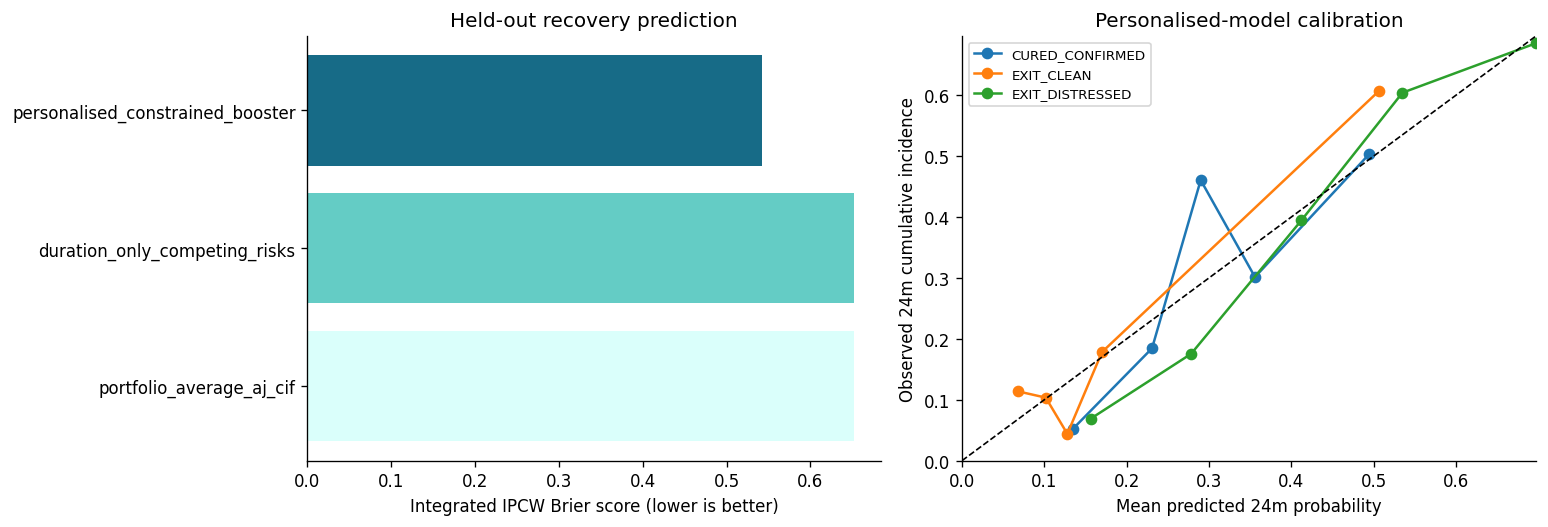


## Final result

**Decision: promote the personalised recovery model.** It produced a statistically credible and material improvement over the same-target duration-only baseline on held-out loans.

- **EWS role:** predicts which performing loans are likely to enter NPL.
- **Recovery role:** predicts cure, clean exit and distressed exit after first NPL.
- **Collections role:** converts the post-NPL probabilities into a transparent priority queue; it does not claim that any action causes recovery.

All tables, the fitted model bundle and the summary figure were saved to `/content/drive/MyDrive/FIP_NPL_Project/model_outputs_personalised_recovery`.


In [13]:
ibs = test_metrics.loc[
    test_metrics["metric"].eq("integrated_multistate_ipcw_brier_1_24m")
].sort_values("value")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(ibs["model"], ibs["value"], color=["#176B87", "#64CCC5", "#DAFFFB"][:len(ibs)])
axes[0].invert_yaxis()
axes[0].set_xlabel("Integrated IPCW Brier score (lower is better)")
axes[0].set_title("Held-out recovery prediction")

cal24 = calibration.loc[calibration["horizon_m"].eq(24)]
for outcome, group in cal24.groupby("outcome"):
    axes[1].plot(group["mean_predicted_cif"], group["observed_aj_cif"], marker="o", label=outcome)
limit = max(0.05, cal24[["mean_predicted_cif", "observed_aj_cif"]].max().max())
axes[1].plot([0, limit], [0, limit], linestyle="--", color="black", linewidth=1)
axes[1].set_xlim(0, limit)
axes[1].set_ylim(0, limit)
axes[1].set_xlabel("Mean predicted 24m probability")
axes[1].set_ylabel("Observed 24m cumulative incidence")
axes[1].set_title("Personalised-model calibration")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "personalised_recovery_model_summary.png", dpi=160, bbox_inches="tight")
plt.show()

if PERSONALISED_PROMOTED:
    conclusion = (
        "**Decision: promote the personalised recovery model.** It produced a statistically credible and "
        "material improvement over the same-target duration-only baseline on held-out loans."
    )
else:
    conclusion = (
        "**Decision: retain the duration-only recovery model.** The loan-level model did not satisfy the "
        "pre-declared paired improvement rule; this is an evidence-based negative result, not a failed run."
    )

display(Markdown(f"""
## Final result

{conclusion}

- **EWS role:** predicts which performing loans are likely to enter NPL.
- **Recovery role:** predicts cure, clean exit and distressed exit after first NPL.
- **Collections role:** converts the post-NPL probabilities into a transparent priority queue; it does not claim that any action causes recovery.

All tables, the fitted model bundle and the summary figure were saved to `{OUTPUT_DIR}`.
"""))
